In [34]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from aml_project.environments.AblatedLettuceGreenhouse import AblatedLettuceGreenhouse


# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([5.0, 0.05])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high), c_r_RH (RH), c_r_co2_vent (CO2+vent), c_coact (heat+vent action)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4,  # u1, u2, u3
                           0.5,                             # c_r_co2_1
                           0.6, 0.3,                        # c_r_T1, c_r_T2
                           0.5,                            # c_r_RH
                           0.001, 0.06])                     # c_r_co2_vent, c_coact
weather_file = root_dir + r"\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat"

# Define the ablation runs
ABLATIONS = {
    "full":        [0, 1, 2],
    "co2_only":    [0],
    "vent_only":   [1],
    "heating_only":[2],
    "heuristic_only": []
}

rresults = {}

for run_name, active in ABLATIONS.items():
    print(f"\n{'='*40}")
    print(f"Run: {run_name}  |  RL controls: {active}")
    print('='*40)

    # --- Build env ---
    base_env = AblatedLettuceGreenhouse(
        active_actions=active,
        weather_data_dir=weather_file,
        reward_coefs=custom_reward_coefs,
        penalty_coefs=custom_penalty_coefs,
        n_days=40
    )
    vec_env    = DummyVecEnv([lambda e=base_env: e])
    train_env  = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.)

    # Train
    if len(active) > 0:
        model = SAC("MlpPolicy", train_env, verbose=0, learning_rate=1e-3,
                    batch_size=64, device='cpu')
        model.learn(total_timesteps=100)
        model.save(f"sac_{run_name}")
    else:
        model = None

    # Evaluate
    obs  = train_env.reset()
    done = False
    k    = 0
    total_reward = 0.0
    info = {}
    
    N_steps = base_env.N
    ny = base_env.ny
    y_traj = np.zeros((ny, N_steps))
    u_traj = np.zeros((3, N_steps))
    d_traj = np.zeros((4, N_steps)) 
    r_traj = np.zeros(N_steps)       

    while not done and k < base_env.N:
        if model is not None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            action = np.zeros((1, 0), dtype=np.float32)

        # Record physical state before step
        y_traj[:, k] = train_env.get_original_obs()[0][:ny]
        
        # Record weather (d) for this step
        d_traj[:, k] = base_env.d[base_env.timestep]

        obs, reward, dones, infos = train_env.step(action)
        done  = dones[0]
        info  = infos[0]
        
        # Record action and step-wise reward
        u_traj[:, k] = base_env.prev_action
        r_traj[k]    = reward[0]
        
        total_reward += reward[0]
        k += 1
        
    # Trim excess if episode ended early
    y_traj = y_traj[:, :k]
    u_traj = u_traj[:, :k]
    d_traj = d_traj[:, :k]
    r_traj = r_traj[:k]

    # Summarise
    revenue      = np.sum(info["revenue"])
    co2_cost     = np.sum(info["co2_cost"])
    heating_cost = np.sum(info["heating_cost"])
    profit       = revenue - co2_cost - heating_cost
    penalty      = np.sum(info["penalty"])

    #  Save results
    results[run_name] = {
        "revenue":      revenue,
        "co2_cost":     co2_cost,
        "heating_cost": heating_cost,
        "profit":       profit,
        "penalty":      penalty,
        "total_reward": total_reward,
        "y":            y_traj,
        "u":            u_traj,
        "d":            d_traj,
        "r":            r_traj
    }

    print(f"  Revenue      : {revenue:.2f}")
    print(f"  Profit       : {profit:.2f}")
    print(f"  Total reward : {total_reward:.2f}")


Run: full  |  RL controls: [0, 1, 2]
  Revenue      : 1434.21
  Profit       : 979.63
  Total reward : -220756.76

Run: co2_only  |  RL controls: [0]


c:\Users\dylan\anaconda3\envs\AdvancedML\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 0.68GB > 0.61GB
  warnings.warn(


  Revenue      : 1350.93
  Profit       : 977.75
  Total reward : -269886.17

Run: vent_only  |  RL controls: [1]


c:\Users\dylan\anaconda3\envs\AdvancedML\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 0.68GB > 0.64GB
  warnings.warn(


  Revenue      : 1443.98
  Profit       : 1069.11
  Total reward : -130615.27

Run: heating_only  |  RL controls: [2]
  Revenue      : 1296.05
  Profit       : 834.33
  Total reward : -336635.66

Run: heuristic_only  |  RL controls: []
  Revenue      : 1454.28
  Profit       : 1079.41
  Total reward : -274884.03


In [35]:
import pandas as pd

df = pd.DataFrame(results).T
df["profit/|penalty|"] = df["profit"] / df["penalty"].abs()
print(df.round(2).to_string())

                    revenue  co2_cost heating_cost       profit        penalty   total_reward                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

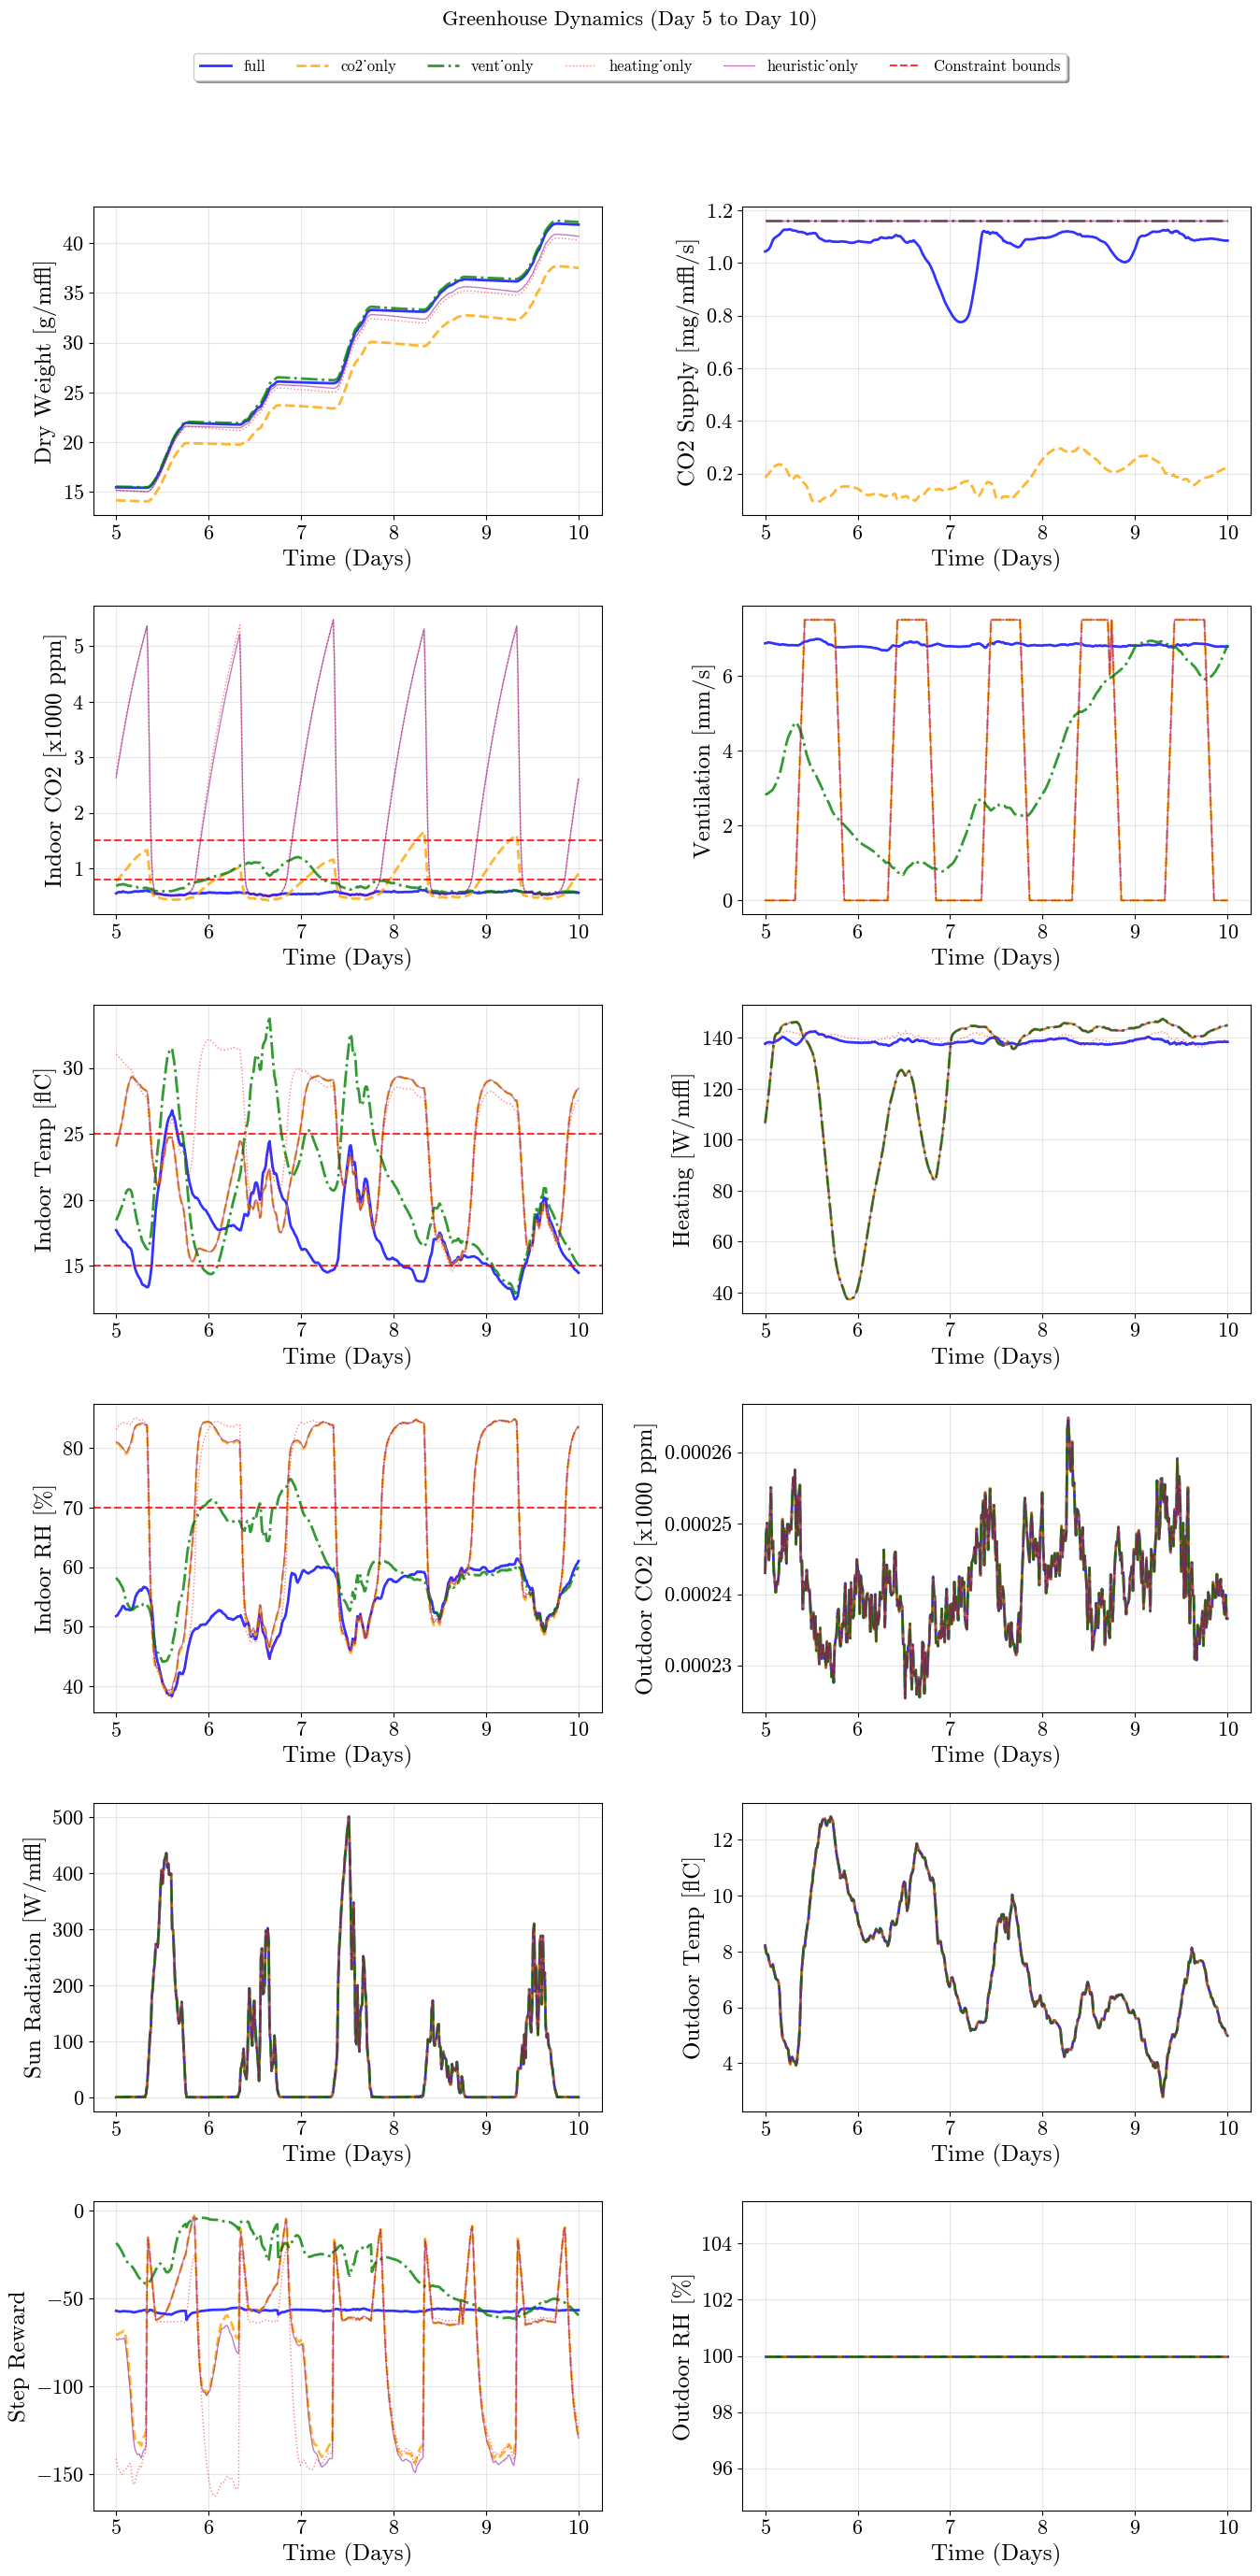

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from aml_project.common.helper_functions import weather2ppmrh

def plot_all_runs_comparison(results_dict, start_day=0, end_day=None, total_days=40):
    """
    Plots the trajectories, actions, weather, and rewards of multiple runs.
    """
    first_key = list(results_dict.keys())[0]
    sample_y = results_dict[first_key]["y"]
    
    N = sample_y.shape[1] 
    steps_per_day = N / total_days
    
    idx_start = int(start_day * steps_per_day)
    if end_day is None:
        idx_end = N
        end_day = total_days
    else:
        idx_end = int(end_day * steps_per_day)
        
    t = np.linspace(start_day, end_day, idx_end - idx_start)
    
    fig, axes = plt.subplots(6, 2, figsize=(14, 28))
    
    labels_left = ['Dry Weight [g/m²]', 'Indoor CO2 [x1000 ppm]', 'Indoor Temp [°C]', 'Indoor RH [%]', 'Sun Radiation [W/m²]', 'Step Reward']
    labels_right = ['CO2 Supply [mg/m²/s]', 'Ventilation [mm/s]', 'Heating [W/m²]', 'Outdoor CO2 [x1000 ppm]', 'Outdoor Temp [°C]', 'Outdoor RH [%]']
    
    colors = ["blue", "orange", "green", "red", "purple"]
    line_styles = ['-', '--', '-.', ':', '-']
    
    for i, (run_name, data) in enumerate(results_dict.items()):
        y, u, r, d_raw = data['y'], data['u'], data['r'], data['d']
        
        try:
            d_conv = weather2ppmrh(d_raw.T).T
            d_conv[1] = d_conv[1] * 1e-3 
        except Exception:
            d_conv = d_raw 
            
        c = colors[i % len(colors)]
        ls = line_styles[i % len(line_styles)]
        
        # Reduce visual dominance of red and purple so they don't hide the others
        lw = 1.0 if c in ["red", "purple"] else 2.0
        al = 0.5 if c in ["red", "purple"] else 0.8
        
        # Left Column 
        for j in range(4):
            axes[j, 0].plot(t, y[j, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        
        axes[4, 0].plot(t, d_conv[0, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        axes[5, 0].plot(t, r[idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        
        # Right Column
        for j in range(3):
            axes[j, 1].plot(t, u[j, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
            
        axes[3, 1].plot(t, d_conv[1, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        axes[4, 1].plot(t, d_conv[2, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        axes[5, 1].plot(t, d_conv[3, idx_start:idx_end], label=run_name, color=c, linestyle=ls, alpha=al, linewidth=lw)
        
    # Formatting & Constraints
    for j in range(6):
        axes[j, 0].set_ylabel(labels_left[j])
        axes[j, 0].grid(True, alpha=0.3)
        axes[j, 1].set_ylabel(labels_right[j])
        axes[j, 1].grid(True, alpha=0.3)

    axes[1, 0].axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Constraint bounds')
    axes[1, 0].axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[2, 0].axhline(y=25, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[2, 0].axhline(y=15, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[3, 0].axhline(y=70, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

    for ax in axes.flat:
        ax.set_xlabel("Time (Days)")
        ax.tick_params(labelbottom=True)

    handles, labels = axes[1, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.96), 
               ncol=len(results_dict) + 1, fancybox=True, shadow=True, fontsize=12)
    
    plt.suptitle(f"Greenhouse Dynamics (Day {start_day} to Day {end_day})", y=0.99, fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_all_runs_comparison(results, start_day=5, end_day=10)